# Item Fit Diagnostics and Residual Checks

This notebook showcases **diagnostics** that are closely related to ICC fit:

- Item **infit/outfit** statistics
- Item **chi-square** fit based on ability groups
- Residual plots by ability
- Model fit summary (**M2/RMSEA/CFI/TLI/SRMSR**) and **Q3** residual correlations

These are key tools for checking **whether estimated ICCs match your data**.

## 0) Install plotting dependency (one-time)

These plots use `matplotlib`. If you don't have it yet, run:

```bash
pip install matplotlib
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from irt import fit
from irt import diagnostics
from irt import plotting

## 1) Load data and fit a model

We'll use the LSAT dataset from the R `ltm` references and fit a Rasch model.

In [2]:
lsat = pd.read_csv("../tests/ltm_reference/lsat_data.csv")

result = fit(lsat, model="rasch", estimator="mml_em", technical={"quadpts": 21})
result

FitResult(model='rasch', estimator='mml_em', n_items=5, n_persons=1000, n_iter=10, converged, loglik=-2473.07)

## 3) Model fit summary (M2/RMSEA/CFI/TLI/SRMSR)

The `model_fit()` method summarizes global fit and residual-based indices, including Q3 summaries for local dependence.

In [ ]:
fit_stats = result.model_fit(method="eap")
fit_stats

## 2) Ability estimates (needed for item fit)

Diagnostics compare **observed responses** to **expected responses** given ability, so we first compute EAP scores.

In [3]:
scores = result.score(method="eap")
theta = scores.theta

theta[:5]

array([-2.03362436, -2.03362436, -2.03362436, -1.52782862, -1.52782862])

## 3) Infit and outfit statistics for items

These tell you whether an item behaves as expected across the ability scale.

- **Infit** is sensitive to unexpected responses near a person's ability.
- **Outfit** is sensitive to extreme outliers.

In [4]:
infit_ms, infit_z, outfit_ms, outfit_z = diagnostics.infit_outfit_items(
    X=result.X,
    mask_obs=result.mask_obs,
    theta=theta,
    a=result.params["a"],
    b=result.params["b"],
)

infit_ms, outfit_ms

(array([1.1170654 , 0.8715714 , 0.79240679, 0.91458573, 1.03465952]),
 array([0.80792438, 0.77982518, 0.7654395 , 0.78817032, 0.8062132 ]))

### Visualize item fit

Green points are typically “good fit”. Red/orange indicate potential misfit.

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Item Fit Statistics'}, xlabel='Infit Mean Square', ylabel='Outfit Mean Square'>)

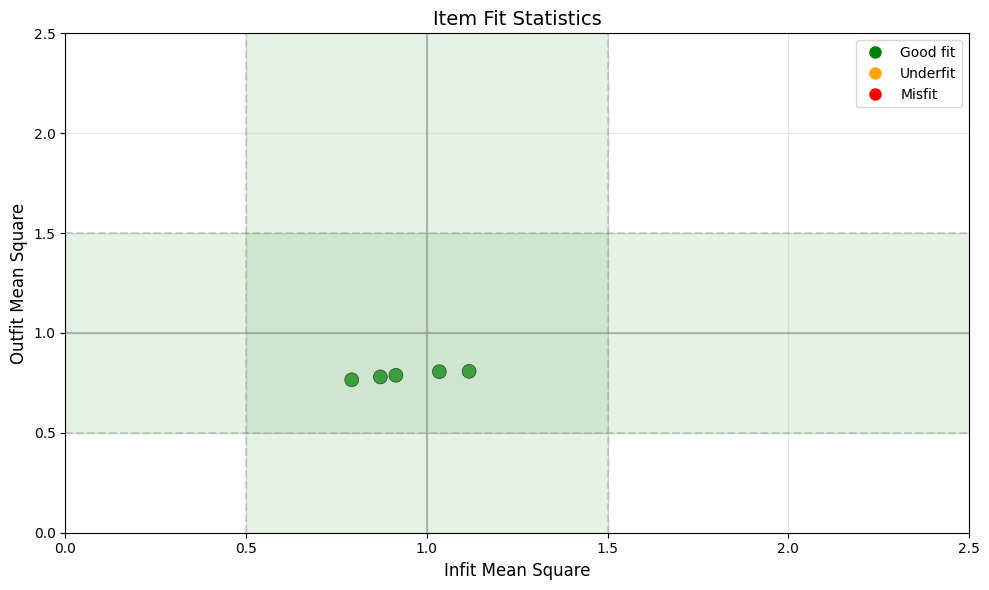

In [5]:
plotting.plot_item_fit(
    infit_ms=infit_ms,
    outfit_ms=outfit_ms,
    b=result.params["b"],
    item_names=result.item_names,
)

## 4) Item chi-square fit (grouped by ability)

This compares observed vs expected proportions across ability groups and produces a **p-value** per item.

In [6]:
chi_sq, df, p_vals = diagnostics.item_chi_square(
    X=result.X,
    mask_obs=result.mask_obs,
    theta=theta,
    a=result.params["a"],
    b=result.params["b"],
    n_groups=10,
)

chi_sq, p_vals

(array([ 89.08428515, 277.71280325, 378.28473153, 372.808824  ,
        141.20836333]),
 array([2.44249065e-15, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]))

### Fit table (all items in one place)

This uses `item_fit_table()` to summarize fit statistics for each item.

In [7]:
fit_table = diagnostics.item_fit_table(
    X=result.X,
    mask_obs=result.mask_obs,
    theta=theta,
    a=result.params["a"],
    b=result.params["b"],
    item_names=result.item_names,
)

fit_table

,item,a,b,n_obs,p_value,disc_emp,rpb,infit_ms,infit_z,outfit_ms,outfit_z,chi_sq,chi_p
0,Item 1,1.0,-2.871865,1000,0.924,0.135135,0.353464,1.117065,0.244137,0.807924,-0.288403,89.084285,2.442491e-15
1,Item 2,1.0,-1.062981,1000,0.709,0.633634,0.566940,0.871571,-1.068102,0.779825,-1.069004,277.712803,0.000000e+00
2,Item 3,1.0,-0.257576,1000,0.553,0.819820,0.627461,0.792407,0.000000,0.765440,0.000000,378.284732,0.000000e+00
3,Item 4,1.0,-1.388004,1000,0.763,0.495495,0.531532,0.914586,-0.386819,0.788170,-0.753030,372.808824,0.000000e+00
4,Item 5,1.0,-2.218701,1000,0.870,0.213213,0.428445,1.034660,0.104397,0.806213,-0.413159,141.208363,0.000000e+00


## 5) Residuals by ability (ICC misfit check)

If the model fits well, residuals should hover around **0** across ability groups.

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Residuals by Ability - Item 1'}, xlabel='Ability ($\\theta$)', ylabel='Mean Residual (Obs - Exp)'>)

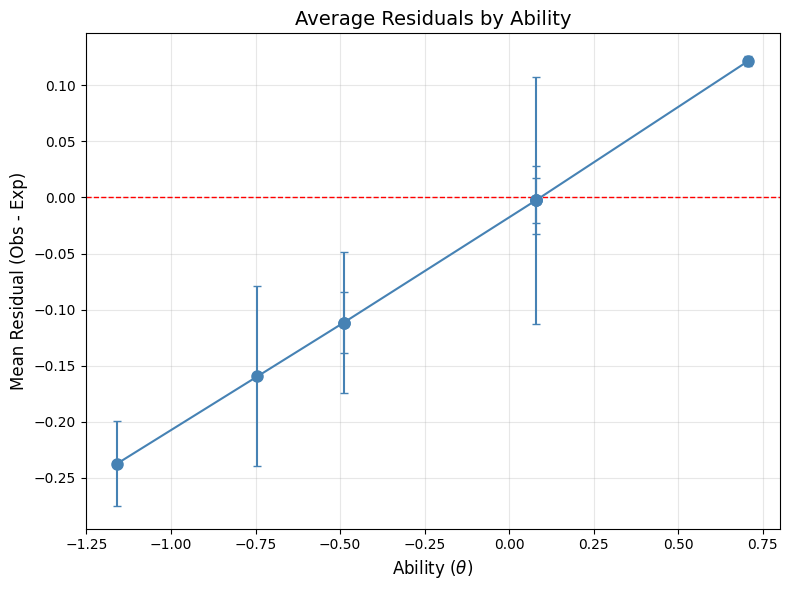

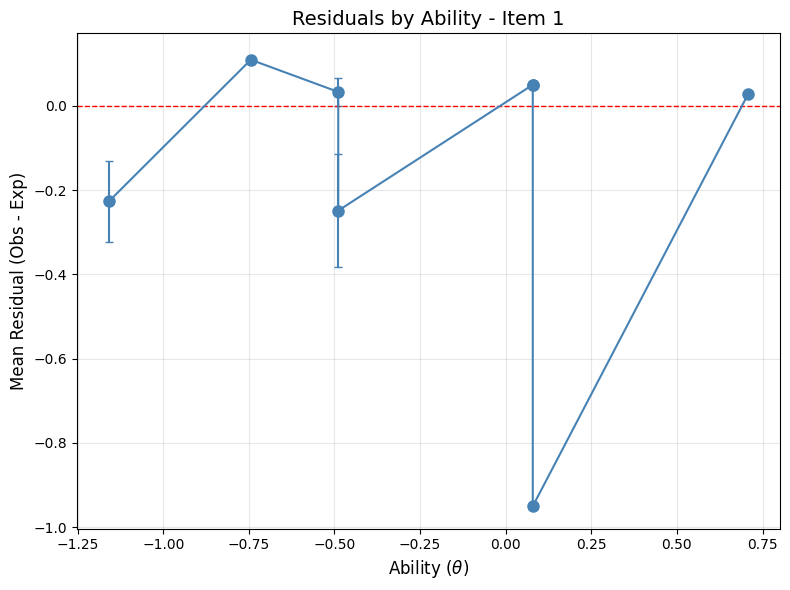

In [8]:
# Residuals averaged across all items
plotting.plot_residuals_by_theta(
    X=result.X,
    mask_obs=result.mask_obs,
    theta=theta,
    a=result.params["a"],
    b=result.params["b"],
    n_groups=10,
)

# Residuals for a single item
plotting.plot_residuals_by_theta(
    X=result.X,
    mask_obs=result.mask_obs,
    theta=theta,
    a=result.params["a"],
    b=result.params["b"],
    item_idx=0,
    n_groups=10,
)

## What you learned

- How to compute **infit/outfit** for items and visualize them
- How to compute **item chi-square** fit statistics and view a summary table
- How to use **residual plots** to diagnose ICC misfit